# Hotel Booking Demand - Exploratory Data Analysis

**Dataset:** `hotel_booking.csv` (119,390 rows, 36 columns)

**Goal:** Perform complete EDA — understand structure, find data quality issues, clean the data, engineer useful features, and visualize key patterns in hotel bookings and cancellations.

**Sections:**
1. Imports & Load Data
2. Initial Exploration
3. Missing Value Analysis
4. Duplicate Analysis
5. Data Cleaning
6. Feature Engineering
7. Univariate Analysis
8. Bivariate / Multivariate Analysis
9. Key Insights Summary
10. Export Cleaned Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

df = pd.read_csv('hotel_booking.csv')
print("Shape:", df.shape)
df.head()


Shape: (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## 2. Initial Exploration

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [3]:
df.describe(include='number').T


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [4]:
df.describe(include='object').T


/tmp/ipykernel_577/607101935.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


## 3. Missing Value Analysis

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_df


,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


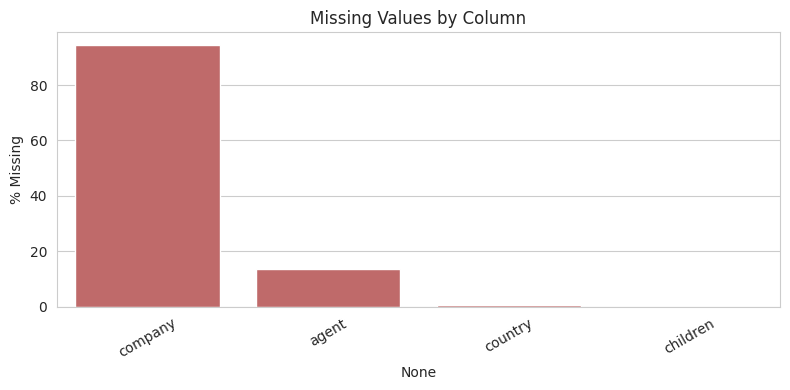

In [6]:
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=missing_df.index, y=missing_df['missing_pct'], ax=ax, color='indianred')
ax.set_ylabel('% Missing')
ax.set_title('Missing Values by Column')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Observations:**
- `company` is missing for ~94% of rows -> not usable as a numeric/categorical feature, will be dropped.
- `agent` missing likely means the booking had no agent (direct booking) -> fill with 0.
- `country` missing for a small % of rows -> fill as 'Unknown'.
- `children` missing for only 4 rows -> fill with 0.


## 4. Duplicate Analysis

The raw file also contains `name`, `email`, `phone-number`, and `credit_card` columns. These look like synthetically generated PII (fake data) attached per row, which can mask true duplicate bookings. Let's check duplicates with and without these columns.

In [7]:
print("Exact duplicate rows (all columns):", df.duplicated().sum())

pii_cols = ['name', 'email', 'phone-number', 'credit_card']
non_pii_cols = [c for c in df.columns if c not in pii_cols]
print("Duplicate rows ignoring PII columns:", df.duplicated(subset=non_pii_cols).sum())


Exact duplicate rows (all columns): 0


Duplicate rows ignoring PII columns: 31994


There are **no exact duplicates**, but once we ignore the fake PII columns, **~32,000 rows (27%)** are true duplicates of another booking record. These will be removed during cleaning, since PII columns provide no analytical value and are a privacy risk.

## 5. Data Cleaning

Steps:
1. Drop PII columns (`name`, `email`, `phone-number`, `credit_card`) - synthetic, not useful, privacy-sensitive.
2. Drop true duplicate rows.
3. Drop `company` (94%+ missing).
4. Fill `agent` missing with 0 (no agent / direct booking).
5. Fill `country` missing with `'Unknown'`.
6. Fill `children` missing with 0.
7. Remove invalid bookings with 0 total guests (adults+children+babies = 0).
8. Remove negative `adr` (average daily rate) values - not physically meaningful.
9. Cap extreme `adr` outliers at the 99.9th percentile.
10. Convert `reservation_status_date` to datetime.


In [8]:
df_clean = df.copy()

# 1. Drop PII columns
df_clean = df_clean.drop(columns=pii_cols)

# 2. Drop true duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed: {before - len(df_clean)}")

# 3. Drop company (too sparse)
df_clean = df_clean.drop(columns=['company'])

# 4. Fill agent missing with 0 (no agent)
df_clean['agent'] = df_clean['agent'].fillna(0).astype(int)

# 5. Fill country missing
df_clean['country'] = df_clean['country'].fillna('Unknown')

# 6. Fill children missing
df_clean['children'] = df_clean['children'].fillna(0).astype(int)

print("Remaining missing values:", df_clean.isna().sum().sum())


Duplicates removed: 31994
Remaining missing values: 0


In [9]:
# 7. Remove invalid bookings with zero guests
zero_guest_mask = (df_clean['adults'] + df_clean['children'] + df_clean['babies']) == 0
print("Zero-guest bookings removed:", zero_guest_mask.sum())
df_clean = df_clean[~zero_guest_mask]

# 8. Remove negative adr
print("Negative adr rows removed:", (df_clean['adr'] < 0).sum())
df_clean = df_clean[df_clean['adr'] >= 0]

# 9. Cap extreme adr outliers at 99.9th percentile
adr_cap = df_clean['adr'].quantile(0.999)
n_capped = (df_clean['adr'] > adr_cap).sum()
df_clean['adr'] = df_clean['adr'].clip(upper=adr_cap)
print(f"adr values capped at {adr_cap:.2f} ({n_capped} rows affected)")

# 10. Convert date column
df_clean['reservation_status_date'] = pd.to_datetime(df_clean['reservation_status_date'])

print("\nCleaned shape:", df_clean.shape)


Zero-guest bookings removed: 166
Negative adr rows removed: 1
adr values capped at 335.00 (85 rows affected)

Cleaned shape: (87229, 31)


## 6. Feature Engineering

In [10]:
df_clean['total_nights'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean['total_guests'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']
df_clean['total_revenue'] = df_clean['adr'] * df_clean['total_nights']
df_clean['is_family'] = ((df_clean['children'] > 0) | (df_clean['babies'] > 0)).astype(int)

# Order months chronologically for correct plotting
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df_clean['arrival_date_month'] = pd.Categorical(df_clean['arrival_date_month'],
                                                 categories=month_order, ordered=True)

df_clean[['total_nights','total_guests','total_revenue','is_family']].describe()


,total_nights,total_guests,total_revenue,is_family
count,87229.000000,87229.000000,87229.000000,87229.000000
mean,3.628461,2.029107,394.770265,0.104357
std,2.742879,0.790146,368.337524,0.305725
min,0.000000,1.000000,0.000000,0.000000
25%,2.000000,2.000000,153.000000,0.000000
50%,3.000000,2.000000,299.200000,0.000000
75%,5.000000,2.000000,504.000000,0.000000
max,69.000000,55.000000,7590.000000,1.000000


## 7. Univariate Analysis

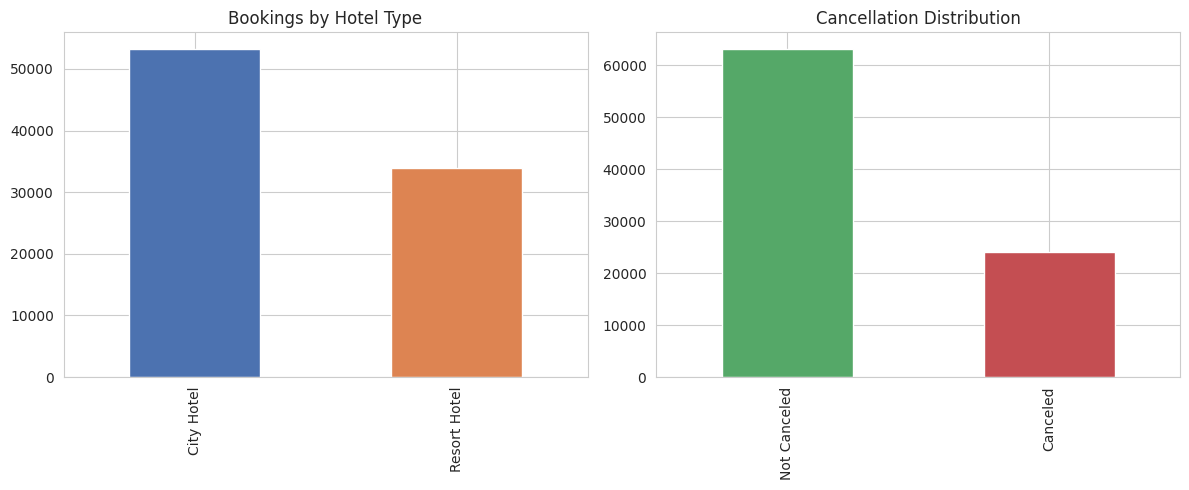

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
df_clean['hotel'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'])
axes[0].set_title('Bookings by Hotel Type')
axes[0].set_xlabel('')

df_clean['is_canceled'].value_counts().rename({0:'Not Canceled',1:'Canceled'}).plot(
    kind='bar', ax=axes[1], color=['#55A868','#C44E52'])
axes[1].set_title('Cancellation Distribution')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()


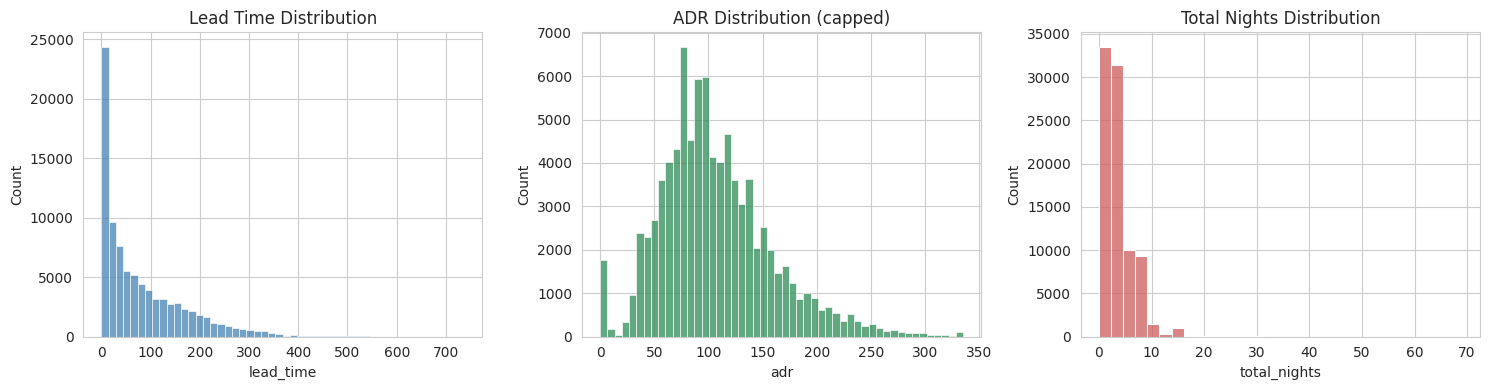

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df_clean['lead_time'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Lead Time Distribution')

sns.histplot(df_clean['adr'], bins=50, ax=axes[1], color='seagreen')
axes[1].set_title('ADR Distribution (capped)')

sns.histplot(df_clean['total_nights'], bins=30, ax=axes[2], color='indianred')
axes[2].set_title('Total Nights Distribution')
plt.tight_layout()
plt.show()


/tmp/ipykernel_577/1837843392.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, palette='viridis')


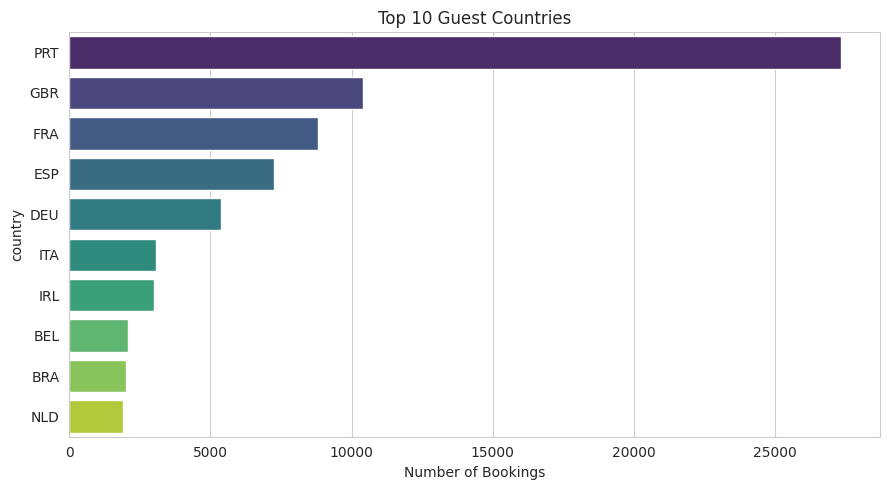

In [13]:
top_countries = df_clean['country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, palette='viridis')
ax.set_title('Top 10 Guest Countries')
ax.set_xlabel('Number of Bookings')
plt.tight_layout()
plt.show()


## 8. Bivariate / Multivariate Analysis

hotel
City Hotel      30.099110
Resort Hotel    23.484023
Name: is_canceled, dtype: float64


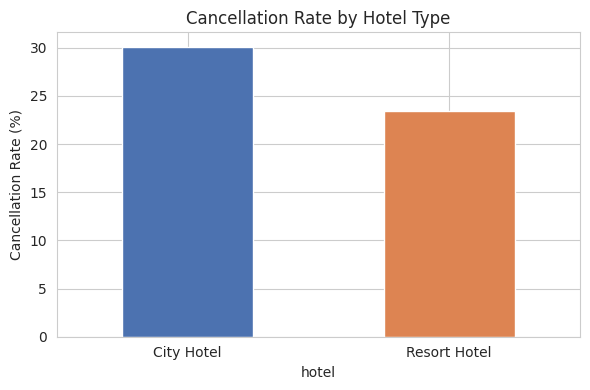

In [14]:
cancel_by_hotel = df_clean.groupby('hotel')['is_canceled'].mean() * 100
print(cancel_by_hotel)

fig, ax = plt.subplots(figsize=(6,4))
cancel_by_hotel.plot(kind='bar', color=['#4C72B0','#DD8452'], ax=ax)
ax.set_ylabel('Cancellation Rate (%)')
ax.set_title('Cancellation Rate by Hotel Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


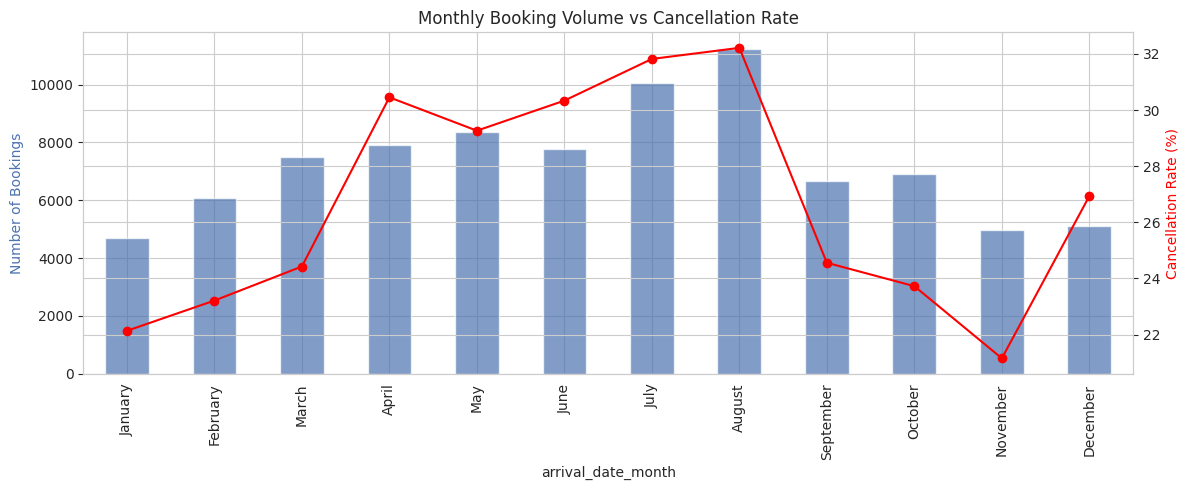

In [15]:
monthly = df_clean.groupby('arrival_date_month', observed=True).agg(
    bookings=('hotel','count'),
    cancel_rate=('is_canceled','mean')
)
monthly['cancel_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()
monthly['bookings'].plot(kind='bar', ax=ax1, color='#4C72B0', alpha=0.7)
monthly['cancel_rate'].plot(ax=ax2, color='red', marker='o')
ax1.set_ylabel('Number of Bookings', color='#4C72B0')
ax2.set_ylabel('Cancellation Rate (%)', color='red')
ax1.set_title('Monthly Booking Volume vs Cancellation Rate')
plt.tight_layout()
plt.show()


/tmp/ipykernel_577/668742351.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Canceled','Canceled'])


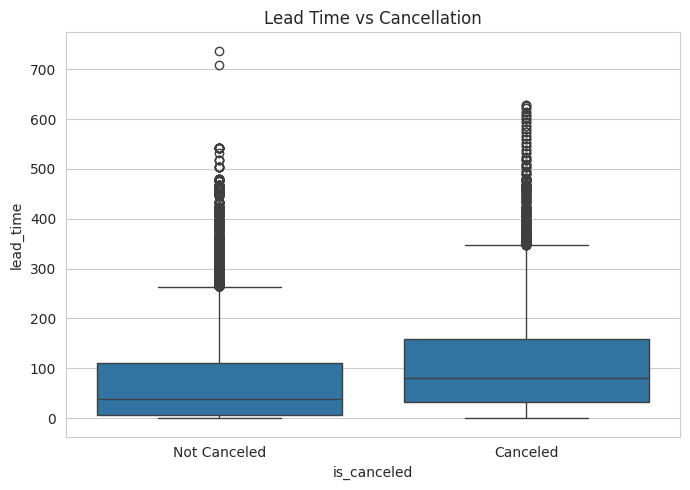

In [16]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df_clean, x='is_canceled', y='lead_time', ax=ax)
ax.set_xticklabels(['Not Canceled','Canceled'])
ax.set_title('Lead Time vs Cancellation')
plt.tight_layout()
plt.show()


/tmp/ipykernel_577/3247752490.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_cancel.values, y=seg_cancel.index, ax=ax, palette='mako')


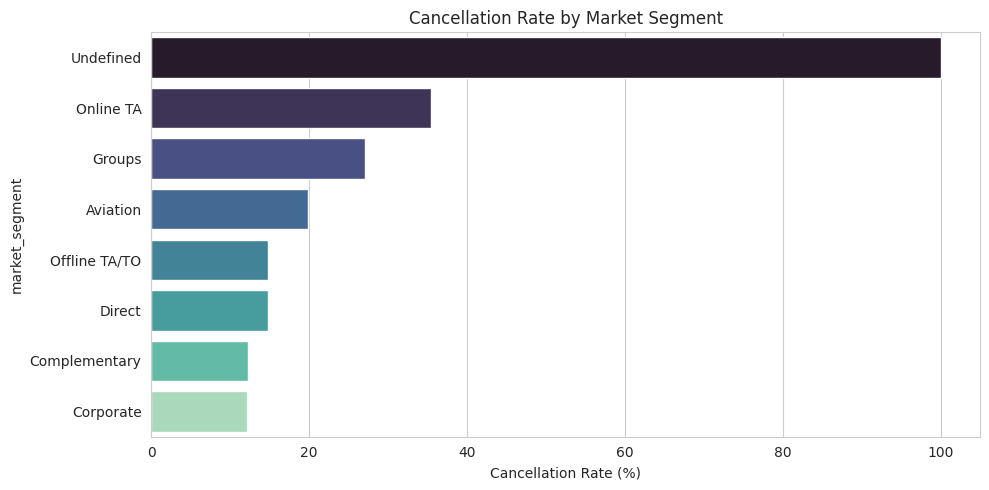

In [17]:
fig, ax = plt.subplots(figsize=(10,5))
seg_cancel = df_clean.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False) * 100
sns.barplot(x=seg_cancel.values, y=seg_cancel.index, ax=ax, palette='mako')
ax.set_xlabel('Cancellation Rate (%)')
ax.set_title('Cancellation Rate by Market Segment')
plt.tight_layout()
plt.show()


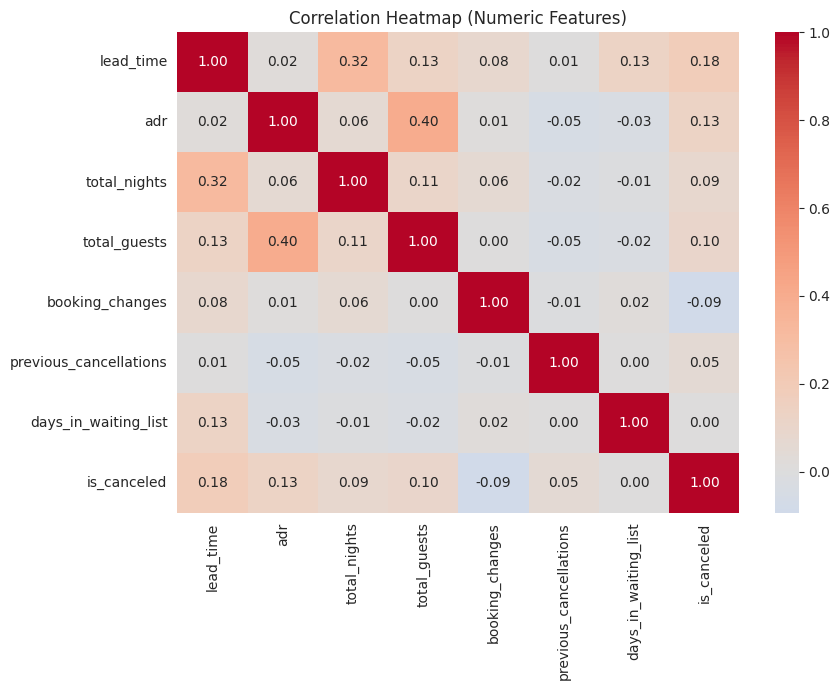

In [18]:
num_cols = ['lead_time','adr','total_nights','total_guests','booking_changes',
            'previous_cancellations','days_in_waiting_list','is_canceled']
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()


## 9. Key Insights Summary

- The dataset had **~32,000 duplicate bookings** hidden behind fake per-row PII (name/email/phone/credit card), and a **94%+ missing `company` column** - both removed during cleaning.
- **City Hotel** has more bookings than **Resort Hotel**, but also a **higher cancellation rate**.
- **Longer lead times are strongly associated with higher cancellation rates** - guests who book far in advance are more likely to cancel.
- Cancellation rates vary a lot **by market segment** - online/group channels tend to cancel more than corporate/direct bookings.
- Booking volume and cancellations both show **clear seasonality**, peaking in summer months.
- `adr` (average daily rate) had negative values and extreme outliers, which were removed/capped for reliable analysis.
- New engineered features (`total_nights`, `total_guests`, `total_revenue`, `is_family`) are ready for use in downstream modeling (e.g. cancellation prediction).


## 10. Export Cleaned Data

In [19]:
df_clean.to_csv('hotel_booking_cleaned.csv', index=False)
print("Saved cleaned dataset:", df_clean.shape)


Saved cleaned dataset: (87229, 35)
